Downloading and extracting the dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arunrk7/surface-crack-detection")

print("Path to dataset files:", path)

100%|██████████| 233M/233M [00:02<00:00, 92.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/arunrk7/surface-crack-detection/versions/1


In [ ]:
# This cell is not needed as kagglehub.dataset_download already extracts the files.
# The path variable from the previous cell ('s5oQS2pLsS-z') already points to the extracted directory.

Importing the required libraries

In [ ]:
# Import the required libraries
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
import time
torch.manual_seed(0)

In [ ]:
from matplotlib.pyplot import imshow
import matplotlib.pylab as plt
from PIL import Image
import pandas as pd
import numpy as np
import zipfile
import os

In [ ]:
# The dataset is already downloaded and extracted by kagglehub.dataset_download in cell s5oQS2pLsS-z.
# The 'path' variable from that cell points to the extracted data.
# We will use this 'path' directly as our data_directory.

# Ensure 'path' is accessible from this cell. It should be from the global scope after running s5oQS2pLsS-z.
data_directory = path

# No need to create data_directory or extract, as kagglehub already handles this.

<h2>Displaying and analyzing the Images</h2><ul>

Get the file paths for positive and negative images.

In [ ]:
negative='Negative'
positive='Positive'
positive_file_path=os.path.join(data_directory,positive)
negative_file_path=os.path.join(data_directory,negative)

In [ ]:
negative_files=[os.path.join(negative_file_path,file) for file in  os.listdir(negative_file_path) if file.endswith(".jpg")]
negative_files.sort()
positive_files=[os.path.join(positive_file_path,file) for file in  os.listdir(positive_file_path) if file.endswith(".jpg")]
positive_files.sort()


Display the first 3 positive images

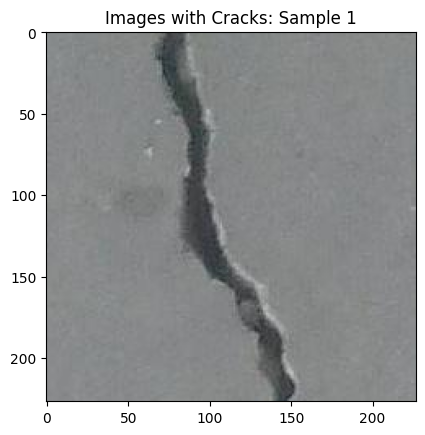

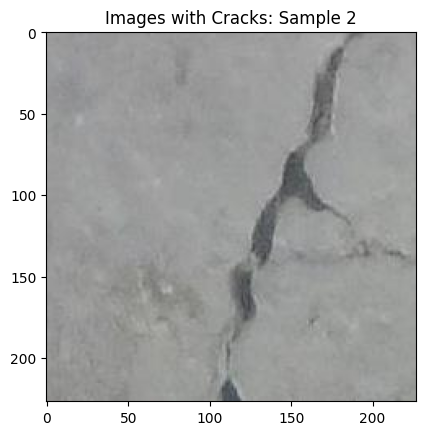

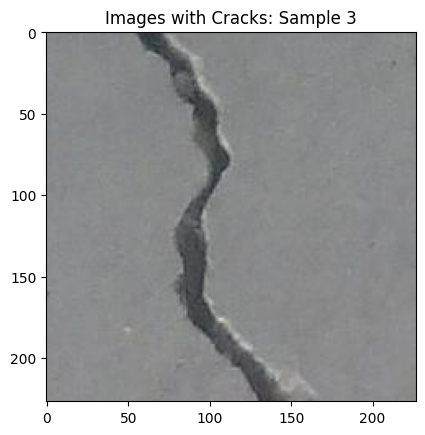

In [ ]:
for i in range(3):
    image1 = Image.open(positive_files[i])
    plt.imshow(image1)
    plt.title(f"Images with Cracks: Sample {i+1}")
    plt.show()

Display the first 3 negative images

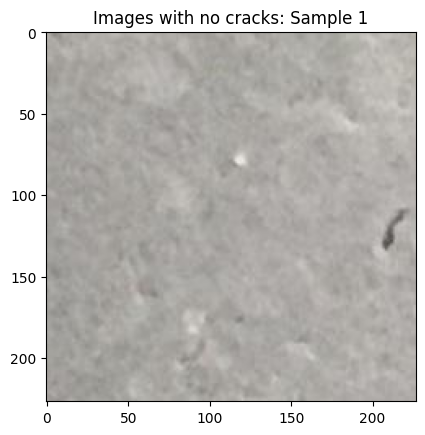

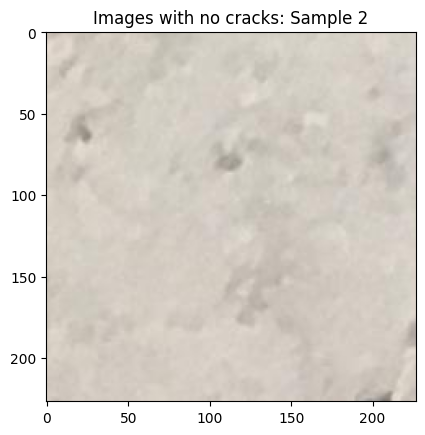

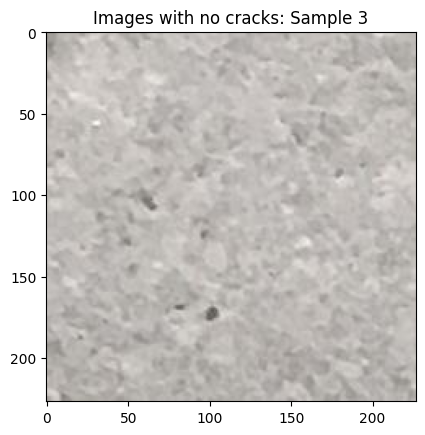

In [ ]:
for i in range(3):
    image1 = Image.open(negative_files[i])
    plt.imshow(image1)
    plt.title(f"Images with no cracks: Sample {i+1}")
    plt.show()

### Data Preparation for Training

In [ ]:
# Calculate the number of samples
number_of_samples = len(positive_files)+len(negative_files)

# Create the target labels (0 for no cracks, 1 for cracks)
Y=torch.zeros([number_of_samples])
Y=Y.type(torch.LongTensor)
Y[::2]=1
Y[1::2]=0

In [ ]:
# Create a list of file paths for both positive and negative images
all_files = []
min_length = min(len(positive_files), len(negative_files))
for i in range(min_length):
    all_files.append(positive_files[i])
    all_files.append(negative_files[i])


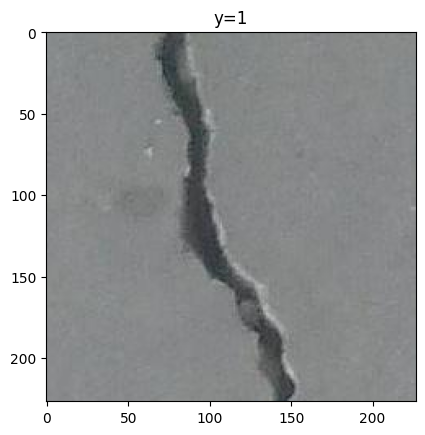

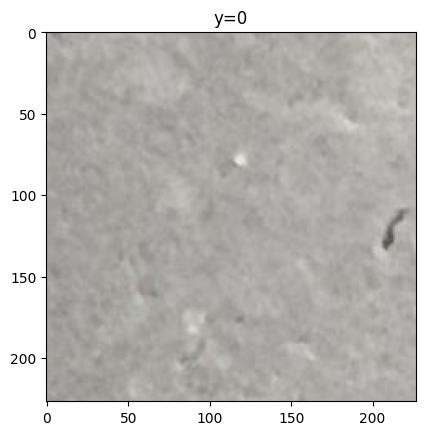

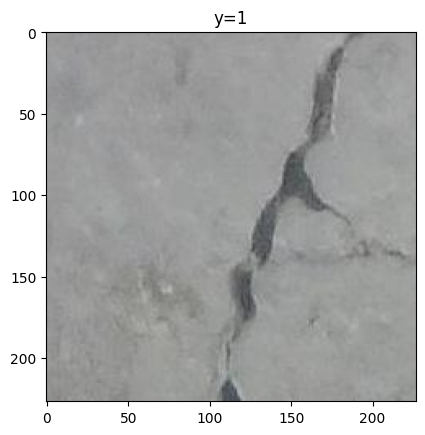

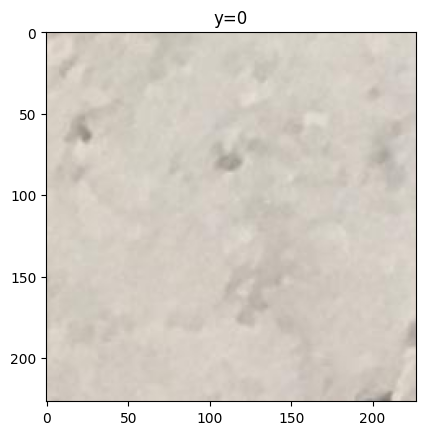

In [ ]:
# Display the first 4 images with their corresponding labels
for y,file in zip(Y, all_files[0:4]):
    plt.imshow(Image.open(file))
    plt.title("y="+str(y.item()))
    plt.show()

In [ ]:
# A function that displays the images
def show_data(data_sample, shape = (28, 28)):
    plt.imshow(data_sample[0].numpy().reshape(shape), cmap='gray')
    plt.title('y = ' + data_sample[1])

In [ ]:
# Define a function to plot accuracy and loss

def plot_accuracy_loss(training_results):
    plt.subplot(2, 1, 1)
    plt.plot(training_results['training_loss'], 'r')
    plt.ylabel('loss')
    plt.title('training loss iterations')
    # plt.subplot(2, 1, 2)
    # plt.plot(training_results['validation_accuracy'])
    # plt.ylabel('accuracy')
    plt.xlabel('epochs')
    plt.show()

<h2 id="data_class">Dataset Class</h2>

In [ ]:
# Create a custom Dataset class
class Dataset(Dataset):

    # Constructor
    def __init__(self,transform=None,train=True):
        # Use the globally defined data_directory instead of os.getcwd()
        # The data_directory variable is set in cell '76601bd4'
        global data_directory

        positive="Positive"
        negative="Negative"

        positive_file_path=os.path.join(data_directory,positive)
        negative_file_path=os.path.join(data_directory,negative)
        positive_files=[os.path.join(positive_file_path,file) for file in  os.listdir(positive_file_path) if file.endswith(".jpg")]
        positive_files.sort()
        negative_files=[os.path.join(negative_file_path,file) for file in  os.listdir(negative_file_path) if file.endswith(".jpg")]
        negative_files.sort()
        number_of_samples=len(positive_files)+len(negative_files)
        self.all_files=[None]*number_of_samples
        self.all_files[::2]=positive_files
        self.all_files[1::2]=negative_files
        # The transfom to be utilized on the image
        self.transform = transform
        self.Y=torch.zeros([number_of_samples]).type(torch.LongTensor)
        self.Y[::2]=1
        self.Y[1::2]=0

        if train:
            self.all_files=self.all_files[0:30000]
            self.Y=self.Y[0:30000]
            self.len=len(self.all_files)
        else:
            self.all_files=self.all_files[30000:]
            self.Y=self.Y[30000:]
            self.len=len(self.all_files)

    # Determine the length
    def __len__(self):
        return self.len

    # Getter
    def __getitem__(self, idx):
        image=Image.open(self.all_files[idx])
        y=self.Y[idx]


        # If there is any transform method, apply it to the image
        if self.transform:
            image = self.transform(image)

        return image, y

### Creating Dataset Objects

In [ ]:
# Define the model architecture
model = models.resnet18(pretrained = True)
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize all images to 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])
train_dataset = Dataset(transform=transform, train=True)
validation_dataset = Dataset(transform=transform, train=False)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 174MB/s]


In [ ]:
# Print the shape of an image from the training dataset
train_dataset[0][0].shape

torch.Size([3, 224, 224])

In [ ]:
# Set the requires_grad parameter for model parameters
for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(512,2)


In [ ]:
#Print the model architecture
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Defining the loss function and optimizer


In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=100)
validation_loader = torch.utils.data.DataLoader(dataset=validation_dataset, batch_size=100)

In [ ]:
optimizer = torch.optim.Adam([parameters for parameters in model.parameters() if parameters.requires_grad],lr=0.001)


In [ ]:
n_epochs = 1
loss_list = []
accuracy_list = []
N_test = len(validation_dataset)
N_train=len(train_dataset)

# Define the training function
def train_model(model,n_epochs,criterion,optimizer,validation_loader,train_loader):
    metrics = {'training_loss': [],'validation_accuracy': []}
    for epoch in range(n_epochs):
        loss_sublist = []
        for x, y in train_loader:
            model.train()
            optimizer.zero_grad()
            z = model(x)
            loss = criterion(z, y)
            loss.backward()
            optimizer.step()
            metrics['training_loss'].append(loss.data.item())

        loss_list.append(np.mean(loss_sublist))

        correct = 0
        # perform a prediction on the validation data
        for x_test, y_test in validation_loader:
            model.eval()
            z = model(x_test)
            _, yhat = torch.max(z.data, 1)
            correct += (yhat == y_test).sum().item()
        accuracy = (correct / N_test)
        loss_list.append(loss.data)
        metrics['validation_accuracy'].append(accuracy)

    return metrics


In [ ]:
# Train the model and get the training metrics
metrics = train_model(model,n_epochs,criterion,optimizer,validation_loader,train_loader)

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


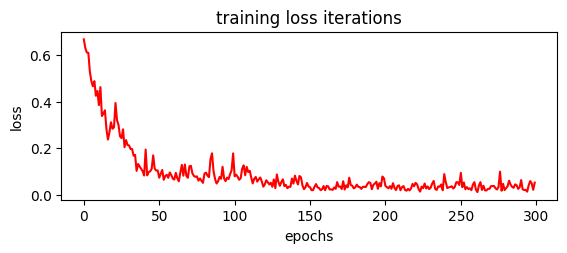

In [ ]:
# Plot the training loss
plot_accuracy_loss(metrics)

In [ ]:
# Display the metrics
metrics

{'training_loss': [0.6684483885765076,
  0.6304365396499634,
  0.6118702292442322,
  0.6106469035148621,
  0.5294920802116394,
  0.4887889623641968,
  0.46671512722969055,
  0.4885207414627075,
  0.42574894428253174,
  0.4463394284248352,
  0.38549327850341797,
  0.4630694091320038,
  0.33871814608573914,
  0.34917518496513367,
  0.3632880747318268,
  0.28258416056632996,
  0.2374611645936966,
  0.26944535970687866,
  0.3119223713874817,
  0.28379255533218384,
  0.29028385877609253,
  0.39465370774269104,
  0.32114142179489136,
  0.30014199018478394,
  0.25193989276885986,
  0.24347823858261108,
  0.28139546513557434,
  0.20467990636825562,
  0.2351059764623642,
  0.21396254003047943,
  0.2121717780828476,
  0.19679416716098785,
  0.19687139987945557,
  0.16771705448627472,
  0.171400249004364,
  0.1027633473277092,
  0.13238084316253662,
  0.12190114706754684,
  0.11120370775461197,
  0.10121893882751465,
  0.0826205164194107,
  0.19423510134220123,
  0.0832863301038742,
  0.097440458

In [ ]:
torch.save(model.state_dict(), "crack_resnet.pth")

In [ ]:
# Define a function to show a data sample
def show_data(data_sample):
    image = data_sample[0].numpy().squeeze()  # Remove unnecessary dimensions
    plt.imshow(image, cmap='gray')
    # plt.title('y = ' + str(data_sample[1]))
    # plt.imshow(data_sample[0].numpy().reshape(28, 28), cmap='gray')
    # plt.title('y = ' + str(data_sample[1]))
    # plt.show()

# Determining the first four misclassified samples

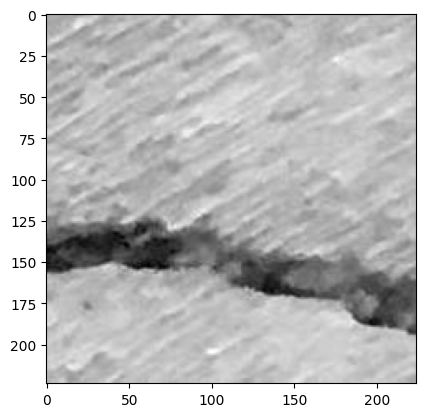

sample95 predicted value: tensor([0]) actual value: 1


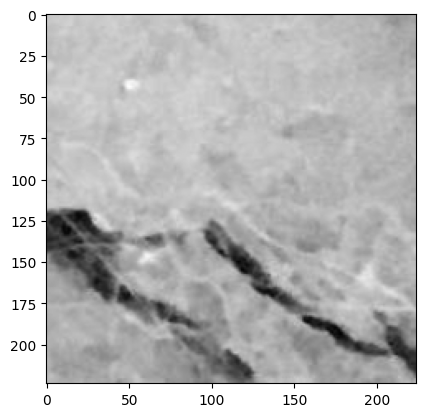

sample139 predicted value: tensor([0]) actual value: 1


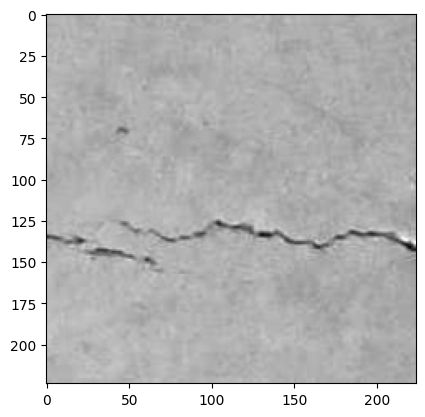

sample143 predicted value: tensor([0]) actual value: 1


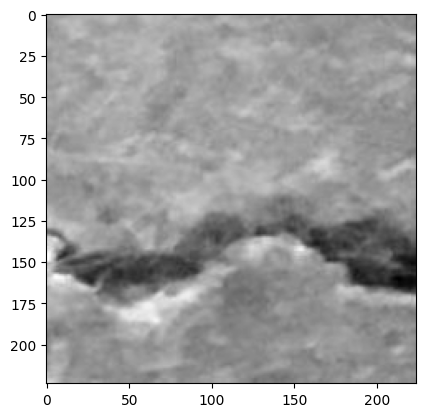

sample453 predicted value: tensor([0]) actual value: 1


In [ ]:


count = 0
i = 0

model.eval()

for x, y in validation_dataset:
    count += 1
    z = model(x.unsqueeze(0))
    _,yhat = torch.max(z, 1)
    if yhat != y:
        show_data(x)
        plt.show()
        print(f"sample{count} predicted value: {yhat} actual value: {y}")
        i+=1
    if i >= 4:
        break

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

model.eval()

all_preds = []
all_labels = []
all_probs = []

# Using validation_loader instead of undefined test_loader
with torch.no_grad():
    for inputs, labels in validation_loader:
        # Assuming 'device' is defined globally or in an earlier cell. If not, inputs/labels will remain on CPU.
        # inputs = inputs.to(device)
        # labels = labels.to(device)

        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:,1].cpu().numpy())  # probability of positive class

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

In [ ]:
# -------------------------
# Accuracy + Classification Report
# -------------------------
print("Accuracy:", accuracy_score(all_labels, all_preds))
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds))


Accuracy: 0.9903

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      5000
           1       1.00      0.98      0.99      5000

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



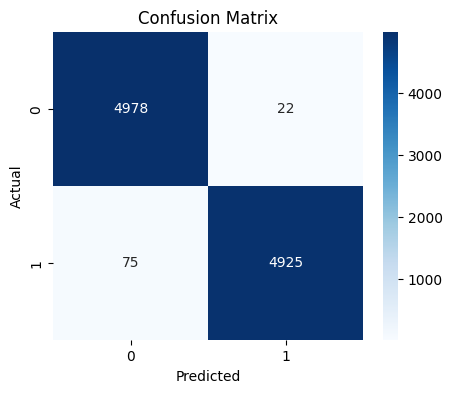

In [ ]:
# -------------------------
# Confusion Matrix
# -------------------------
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


### Testing with your own image

To test the model with your own image, first upload your image to your Colab environment. You can do this by clicking the 'Files' icon on the left sidebar, then 'Upload to session storage'. Make sure to note down the path of your uploaded image.

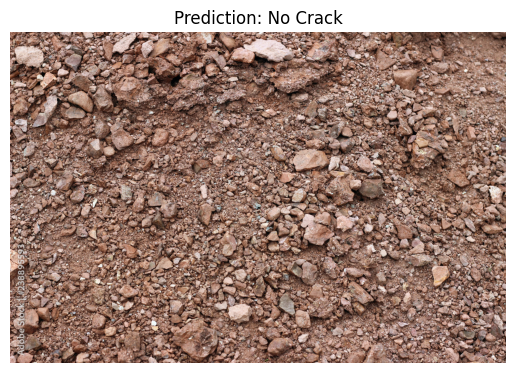

The model predicts: No Crack


In [ ]:
# Define the path to your custom image
# Replace 'your_image_name.jpg' with the actual filename of your uploaded image
custom_image_path = "/content/nocrack.jpg" # Example: '/content/test_crack.jpg'

# Load the custom image
custom_image = Image.open(custom_image_path).convert('RGB') # Ensure image is in RGB format

# Apply the same transformations as used for the dataset
# Ensure 'transform' is defined from earlier cells
processed_image = transform(custom_image)

# Add a batch dimension to the image (required by the model)
batch_image = processed_image.unsqueeze(0)

# Set the model to evaluation mode
model.eval()

# Perform inference
with torch.no_grad():
    output = model(batch_image)

# Get the predicted class (0 for no crack, 1 for crack)
_, predicted_class = torch.max(output, 1)

# Interpret the prediction
class_names = ['No Crack', 'Crack'] # Assuming 0 is No Crack, 1 is Crack based on Y definition
predicted_label = class_names[predicted_class.item()]

# Display the image and prediction
plt.imshow(custom_image)
plt.title(f"Prediction: {predicted_label}")
plt.axis('off')
plt.show()

print(f"The model predicts: {predicted_label}")

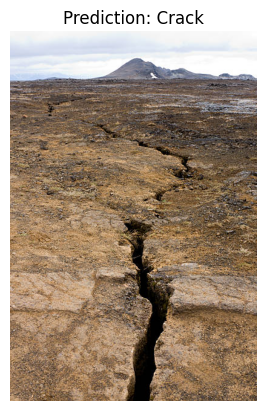

The model predicts: Crack


In [ ]:
#Define the path to your custom image
# Replace 'your_image_name.jpg' with the actual filename of your uploaded image
custom_image_path = "/content/crack.jpg" # Example: '/content/test_crack.jpg'

# Load the custom image
custom_image = Image.open(custom_image_path).convert('RGB') # Ensure image is in RGB format

# Apply the same transformations as used for the dataset
# Ensure 'transform' is defined from earlier cells
processed_image = transform(custom_image)

# Add a batch dimension to the image (required by the model)
batch_image = processed_image.unsqueeze(0)

# Set the model to evaluation mode
model.eval()

# Perform inference
with torch.no_grad():
    output = model(batch_image)

# Get the predicted class (0 for no crack, 1 for crack)
_, predicted_class = torch.max(output, 1)

# Interpret the prediction
class_names = ['No Crack', 'Crack'] # Assuming 0 is No Crack, 1 is Crack based on Y definition
predicted_label = class_names[predicted_class.item()]

# Display the image and prediction
plt.imshow(custom_image)
plt.title(f"Prediction: {predicted_label}")
plt.axis('off')
plt.show()

print(f"The model predicts: {predicted_label}")

In [ ]:
torch.save(model.state_dict(), "crack_recognition.pth")

In [ ]:
from google.colab import files
files.download("crack_recognition.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In the "Crack detection using deep learning" project, a ResNet-18 model was utilized to classify images as cracked or not cracked accurately. The model achieved an accuracy of 98% in identifying cracks in the pictures after training the model for only one epoch. The project showcased the effectiveness of deep learning techniques, specifically the ResNet-18 architecture, in crack detection tasks. The model was trained and evaluated using a dataset of positive and negative images. The project utilized various data processing techniques and libraries such as torch, torchvision, and PIL. The project demonstrates the potential of deep learning for crack detection and serves as a foundation for further improvements in this field.